In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
spicy = pd.read_csv('valentines_day_spending_dataset.csv')
spicy

,user_id,age,gender,city,relationship_status,celebrates_valentine,gift_type,spending_usd,mood,plans,previous_year_spending,sentiment_score
0,1,21,Female,Karachi,Single,No,NaN,118.99,Happy,Family,9.62,-0.59
1,2,45,Female,Rawalpindi,Single,No,NaN,31.41,Excited,Alone,128.50,0.36
2,3,23,Female,Lahore,Taken,No,Chocolates,79.80,Sad,Friends,53.06,-0.74
3,4,27,Male,Islamabad,Single,No,NaN,120.61,Sad,Family,93.27,-0.61
4,5,30,Male,Rawalpindi,Taken,Yes,Flowers,49.88,Excited,Family,137.06,-0.96
...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,26,Female,Karachi,Complicated,No,Flowers,119.82,Excited,Date,68.68,0.18
196,197,21,Male,Rawalpindi,Complicated,No,Dinner,30.79,Sad,Family,24.24,-0.26
197,198,44,Male,Islamabad,Complicated,No,Flowers,89.00,Sad,Alone,71.26,-0.45
198,199,19,Female,Karachi,Single,No,Dinner,143.48,Excited,Alone,90.01,0.98


In [3]:
spicy.columns

Index(['user_id', 'age', 'gender', 'city', 'relationship_status',
       'celebrates_valentine', 'gift_type', 'spending_usd', 'mood', 'plans',
       'previous_year_spending', 'sentiment_score'],
      dtype='object')

In [4]:
spicy['gender'].unique()

array(['Female', 'Male'], dtype=object)

In [5]:
spicy['gender'].value_counts()

gender
Female    107
Male       93
Name: count, dtype: int64

In [6]:
spicy['relationship_status'].value_counts()

relationship_status
Taken          73
Complicated    66
Single         61
Name: count, dtype: int64

In [7]:
counts = spicy.groupby(['gender', 'relationship_status']).size()
counts

gender  relationship_status
Female  Complicated            36
        Single                 30
        Taken                  41
Male    Complicated            30
        Single                 31
        Taken                  32
dtype: int64

In [8]:
percentages = counts.groupby(level=0).apply(
    lambda x: 100 * x / x.sum()
)
percentages

gender  gender  relationship_status
Female  Female  Complicated            33.644860
                Single                 28.037383
                Taken                  38.317757
Male    Male    Complicated            32.258065
                Single                 33.333333
                Taken                  34.408602
dtype: float64

In [10]:
# counts: your Series
percentages = counts.groupby(level=0).apply(lambda x: 100 * x / x.sum())
print(percentages)

gender  gender  relationship_status
Female  Female  Complicated            33.644860
                Single                 28.037383
                Taken                  38.317757
Male    Male    Complicated            32.258065
                Single                 33.333333
                Taken                  34.408602
dtype: float64


In [12]:
spicy.mood.unique()

array(['Happy', 'Excited', 'Sad', 'Neutral'], dtype=object)

In [13]:
mood_counts = spicy.groupby(['gender', 'mood','gift_type']).size()
mood_counts

gender  mood     gift_type 
Female  Excited  Chocolates     9
                 Dinner         5
                 Flowers        9
        Happy    Chocolates     5
                 Dinner         2
                 Flowers       10
        Neutral  Chocolates     7
                 Dinner         5
                 Flowers        7
        Sad      Chocolates     6
                 Dinner         9
                 Flowers        7
Male    Excited  Chocolates     3
                 Dinner         7
                 Flowers        6
        Happy    Chocolates     7
                 Dinner         5
                 Flowers        5
        Neutral  Chocolates     4
                 Dinner         2
                 Flowers        7
        Sad      Chocolates     3
                 Dinner         6
                 Flowers        8
dtype: int64

In [50]:
import sklearn
print(sklearn.__version__)
from sklearn.cluster import KMeans

1.7.2


In [51]:
X = spicy[['age','spending_usd','previous_year_spending']]

In [52]:
kmeans = KMeans(n_clusters=2)

In [53]:
kmeans.fit(X)

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [55]:
spicy['cluster'] = kmeans.labels_

In [57]:
print(spicy[['age','spending_usd','previous_year_spending','cluster']].head())

   age  spending_usd  previous_year_spending  cluster
0   21        118.99                    9.62        0
1   45         31.41                  128.50        1
2   23         79.80                   53.06        0
3   27        120.61                   93.27        1
4   30         49.88                  137.06        1


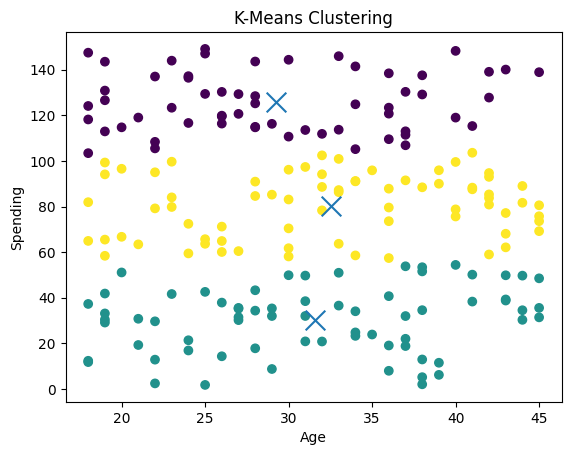

In [60]:
# select two numeric features
X = spicy[['age','spending_usd']]   # change if column names are different

# apply KMeans
kmeans = KMeans(n_clusters=3)
clusters = kmeans.fit_predict(X)

# plot clusters
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=clusters)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], marker='x', s=200)

plt.xlabel("Age")
plt.ylabel("Spending")
plt.title("K-Means Clustering")
plt.show()

In [61]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

NameError: name 'X_scaled' is not defined